In [329]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
import xarray as xr
import numpy as np
import pandas as pd
import pygmt

making dicts in dicts for each layer

dens in $kg/m^3$, thick in m

In [330]:
layers = {
    'water': {'thickness': 2000, 'density': 1030, 'color': 'blue'},
    'sediment': {'thickness': 445,  'density': 1880, 'color': 'tan'},
    'crust': {'thickness': 8000, 'density': 2750, 'color': 'sienna'},
    'mantle': {'thickness': 3000,'density': 3200, 'color': 'red'}}

"The buried sphere model has contrast density $\Delta \rho$. The gravitational acceleration anomaly at observation point $P$ caused by the sphere is $\Delta g_r$, so the vertical component will be $\Delta g$. We can compute the $\Delta g$ by using this equation


\begin{align*}
\Delta g = \frac{G z \Delta \rho V}{(x^2+z^2)^{3/2}}
\end{align*}


To obtained gravitational acceleration anomaly over the buried sphere we use the equation above.

>defining sphere params as well as volume

rho (density contrast) in $kg/m^3$

In [331]:
rho = 500
r = 500
z = 2500

# calculating the volume 
v = 4 / 3 * np.pi * r**3

L: survey is 1000m long

dL: 10m spacing

s: sphere is 500m along the survey

In [332]:
L = 1000
dL = 10
s = 500

s: the horizontal distance between each measurement station and the sphere.

In [333]:
G = 6.674 * 1e-11  # grav constant
dx = np.arange(0, L, dL)  # matrix of survey
x = dx - s

n: denominator in the gravity equation.

g is the gravitational attraction of a point mass approximation:

In [334]:
n = (x**2 + z**2) ** 1.5 
g = G * rho * v *z / n * 1e5  # m/s^2 -> mGal 

The higher top is, the closer the top subplot gets to the title.

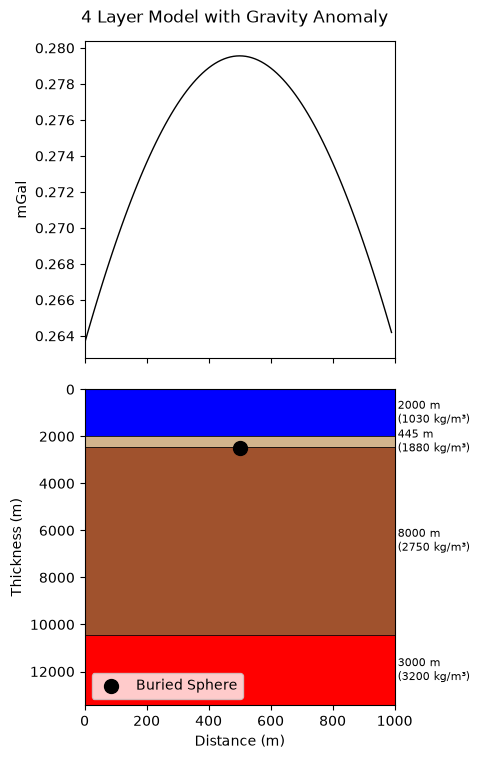

In [346]:
fig, (ax0, ax1) = plt.subplots(2,1, figsize=(4, 8), sharex=True)

ax0.plot(dx, g, color='black', label='Gravitational Anomaly', linewidth=1)
ax0.set_ylabel('mGal')

# defining poly geom
x0 = 0
x1 = L
bottom = 0

polys = {}

# name is key, l is value
for name, l in layers.items():
    # print(f'name: {name}\n l: {l}')
    n = l['thickness']
    rho_l = l['density']
    top = bottom + n

    #bl, br, tl, tr
    verts = [(x0, bottom), (x1, bottom),
        (x1, top), (x0, top)]

    poly = Polygon(verts, closed=True, facecolor=l['color'], edgecolor='black', linewidth=0.5)
    ax1.add_patch(poly)

    ax1.text(x0 + (x1 - x0) + 10, bottom + n/2, f'{n} m\n({rho_l} kg/m³)', 
             va='center', ha='left', fontsize=8)

    # stores the polygon under its layer name in the dict 
    polys[name] = poly

    bottom += n

# loc of sphere vs depth
ax1.scatter(s, z, color='black', marker='o', s=100, label='Buried Sphere')

ax1.set_xlim(0, x1)
ax1.set_ylim(0, bottom)
ax1.set_ylabel('Thickness (m)')
ax1.set_xlabel('Distance (m)')
ax1.invert_yaxis()
ax1.legend(loc='lower left', fontsize=10)


fig.suptitle('4 Layer Model with Gravity Anomaly', fontsize=12)
fig.subplots_adjust(top=0.94, hspace=0.1)

plt.savefig('..\\..\\figures\\4lay\\4laymod.png', dpi=400)
plt.show()